# Imports :

In [96]:
import pandas as pd
import numpy as np
import pickle
import re
import matplotlib.pyplot as plt
from difflib import get_close_matches,SequenceMatcher
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from wordcloud import WordCloud 

In [98]:
df = pd.read_csv("D:\Graduation Project\Recommender System/Egyptian_Food_CLEANED.csv")
df

<>:1: SyntaxWarning: invalid escape sequence '\G'
<>:1: SyntaxWarning: invalid escape sequence '\G'
C:\Users\muhaned\AppData\Local\Temp\ipykernel_21604\3732337448.py:1: SyntaxWarning: invalid escape sequence '\G'
  df = pd.read_csv("D:\Graduation Project\Recommender System/Egyptian_Food_CLEANED.csv")


,food_id,food_name_ar,food_name_en,ingredients_ar,ingredients_en,description_ar,description_en,main_category_ar,main_category_en,calorie_category,...,user_11_rating,user_12_rating,user_13_rating,user_14_rating,user_15_rating,user_16_rating,user_17_rating,user_18_rating,user_19_rating,user_20_rating
0,1,كشري,Koshari,مكرونة، عدس، أرز، صلصة طماطم، بصل مقلي,"Pasta, lentils, rice, tomato sauce, fried onions",أكلة مصرية شهيرة تجمع بين المكرونة والعدس والأ...,"A famous Egyptian dish combining pasta, lentil...",نباتي,Vegetarian,Medium,...,4.0,NaN,NaN,NaN,4.0,2.0,2.0,NaN,NaN,5.0
1,2,ملوخية,Molokhia,ورق ملوخية، ثوم، مرقة دجاج,"Molokhia leaves, garlic, chicken broth",طبق شعبي من أوراق الملوخية المطبوخة بالثوم وال...,A traditional soup made from jute leaves cooke...,نباتي,Vegetarian,Low,...,NaN,3.0,1.0,NaN,5.0,NaN,NaN,NaN,1.0,2.0
2,3,طعمية,Falafel,فول مدمس، بصل، بقدونس، كزبرة,"Fava beans, onion, parsley, coriander",أقراص مقلية مصنوعة من الفول المدمس والأعشاب,Fried patties made from fava beans and herbs.,نباتي,Vegetarian,Medium,...,NaN,NaN,NaN,NaN,5.0,NaN,NaN,1.0,NaN,1.0
3,4,فتة,Fattah,أرز، خبز محمص، صلصة طماطم، لحم,"Rice, toasted bread, tomato sauce, meat",أكلة مصرية تُقدّم عادة في المناسبات وتتكوّن من...,"A celebratory Egyptian dish made with rice, to...",لحوم,Meat,High,...,5.0,NaN,3.0,NaN,NaN,3.0,NaN,NaN,NaN,NaN
4,5,محشي كرنب,Stuffed Cabbage,كرنب، أرز، صلصة طماطم، بصل,"Cabbage, rice, tomato sauce, onion",ورق كرنب محشي بالأرز والخضار والصلصة.,"Cabbage leaves stuffed with rice, herbs, and t...",نباتي,Vegetarian,Medium,...,5.0,NaN,2.0,NaN,NaN,NaN,NaN,3.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772,30182,فطيرة الموز والتوفي,Banana Toffee Pie,موز، كريمة، توفي، بسكويت، زبدة,"Banana, cream, toffee, biscuits, butter",فطيرة الموز والتوفي البريطانية اللذيذة,Delicious British banana toffee pie.,حلويات,Dessert,High,...,NaN,NaN,NaN,NaN,3.0,NaN,5.0,4.0,NaN,3.0
773,30183,كريم بروليه بالفانيليا,Classic Crème Brûlée,قشطة، بيض، فانيليا، سكر,"Cream, eggs, vanilla, sugar",كريم بروليه فرنسي كلاسيكي مع طبقة السكر المحرقة,Classic French crème brûlée with burnt sugar c...,حلويات,Dessert,High,...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN
774,30184,سوفليه الليمون,Lemon Soufflé,بيض، ليمون، سكر، دقيق، زبدة,"Eggs, lemon, sugar, flour, butter",سوفليه الليمون الخفيف الهوائي المميز بنكهة حامضة,Light and airy lemon soufflé with tangy flavor.,حلويات,Dessert,Medium,...,NaN,4.0,NaN,NaN,4.0,1.0,NaN,NaN,NaN,3.0
775,30185,آيس كريم الخوخ الطبيعي,Natural Peach Ice Cream,خوخ طازج، قشطة، سكر، عصير ليمون,"Fresh peaches, cream, sugar, lemon juice",آيس كريم خوخ طبيعي كريمي ومنعش,Natural creamy and refreshing peach ice cream.,حلويات,Dessert,High,...,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,5.0


In [100]:
df2 = df.iloc[: , 12:16]
df2

,calories_per_100g,fats_per_100g,protein_per_100g,carbs_per_100g
0,140,3.3,4.3,23.3
1,35,0.2,3.5,6.5
2,333,17.8,13.3,31.8
3,177,4.7,9.8,22.8
4,99,2.8,2.0,16.8
...,...,...,...,...
772,380,22.0,4.0,45.0
773,300,20.0,5.0,26.0
774,185,6.0,7.0,27.0
775,195,9.0,2.5,28.0


In [102]:
df.head(5)

,food_id,food_name_ar,food_name_en,ingredients_ar,ingredients_en,description_ar,description_en,main_category_ar,main_category_en,calorie_category,...,user_11_rating,user_12_rating,user_13_rating,user_14_rating,user_15_rating,user_16_rating,user_17_rating,user_18_rating,user_19_rating,user_20_rating
0,1,كشري,Koshari,مكرونة، عدس، أرز، صلصة طماطم، بصل مقلي,"Pasta, lentils, rice, tomato sauce, fried onions",أكلة مصرية شهيرة تجمع بين المكرونة والعدس والأ...,"A famous Egyptian dish combining pasta, lentil...",نباتي,Vegetarian,Medium,...,4.0,NaN,NaN,NaN,4.0,2.0,2.0,NaN,NaN,5.0
1,2,ملوخية,Molokhia,ورق ملوخية، ثوم، مرقة دجاج,"Molokhia leaves, garlic, chicken broth",طبق شعبي من أوراق الملوخية المطبوخة بالثوم وال...,A traditional soup made from jute leaves cooke...,نباتي,Vegetarian,Low,...,NaN,3.0,1.0,NaN,5.0,NaN,NaN,NaN,1.0,2.0
2,3,طعمية,Falafel,فول مدمس، بصل، بقدونس، كزبرة,"Fava beans, onion, parsley, coriander",أقراص مقلية مصنوعة من الفول المدمس والأعشاب,Fried patties made from fava beans and herbs.,نباتي,Vegetarian,Medium,...,NaN,NaN,NaN,NaN,5.0,NaN,NaN,1.0,NaN,1.0
3,4,فتة,Fattah,أرز، خبز محمص، صلصة طماطم، لحم,"Rice, toasted bread, tomato sauce, meat",أكلة مصرية تُقدّم عادة في المناسبات وتتكوّن من...,"A celebratory Egyptian dish made with rice, to...",لحوم,Meat,High,...,5.0,NaN,3.0,NaN,NaN,3.0,NaN,NaN,NaN,NaN
4,5,محشي كرنب,Stuffed Cabbage,كرنب، أرز، صلصة طماطم، بصل,"Cabbage, rice, tomato sauce, onion",ورق كرنب محشي بالأرز والخضار والصلصة.,"Cabbage leaves stuffed with rice, herbs, and t...",نباتي,Vegetarian,Medium,...,5.0,NaN,2.0,NaN,NaN,NaN,NaN,3.0,NaN,NaN


# Data Preprocessing :

In [105]:
df.isna().sum()

food_id                0
food_name_ar           0
food_name_en           0
ingredients_ar         0
ingredients_en         0
description_ar         0
description_en         0
main_category_ar       0
main_category_en       0
calorie_category       0
rating_avg             0
image_url              0
calories_per_100g      0
fats_per_100g          0
protein_per_100g       0
carbs_per_100g         0
user_1_rating        428
user_2_rating        573
user_3_rating        580
user_4_rating        512
user_5_rating        447
user_6_rating        569
user_7_rating        547
user_8_rating        527
user_9_rating        493
user_10_rating       459
user_11_rating       598
user_12_rating       524
user_13_rating       405
user_14_rating       569
user_15_rating       563
user_16_rating       553
user_17_rating       524
user_18_rating       498
user_19_rating       578
user_20_rating       482
dtype: int64

In [107]:
print(df.duplicated().sum())
print(df["food_name_en"].duplicated().sum())

0
17


In [109]:
df.drop_duplicates(subset=["food_name_en"], inplace = True)
df.reset_index(drop=True , inplace=True)

In [111]:
df["Selected_Cols"] = (df['food_name_en'] + ' ') * 1 + \
                       (df['ingredients_en'] + ' ') * 2 + \
                       (df['description_en'] + ' ') * 2 + \
                       (df['main_category_en'] + ' ') * 2 + \
                       (df['calorie_category'] + ' ') * 2
df["Selected_Cols"]

0      Koshari Pasta, lentils, rice, tomato sauce, fr...
1      Molokhia Molokhia leaves, garlic, chicken brot...
2      Falafel Fava beans, onion, parsley, coriander ...
3      Fattah Rice, toasted bread, tomato sauce, meat...
4      Stuffed Cabbage Cabbage, rice, tomato sauce, o...
                             ...                        
755    Banana Toffee Pie Banana, cream, toffee, biscu...
756    Classic Crème Brûlée Cream, eggs, vanilla, sug...
757    Lemon Soufflé Eggs, lemon, sugar, flour, butte...
758    Natural Peach Ice Cream Fresh peaches, cream, ...
759    Matcha Green Tea Cake Flour, matcha powder, eg...
Name: Selected_Cols, Length: 760, dtype: object

In [113]:
def Text_Preprocessing(text):
    text = re.sub(r"[^A-Za-z0-9\s]",'',text)
    return text

df["Selected_Cols"] = df["Selected_Cols"].apply(Text_Preprocessing)

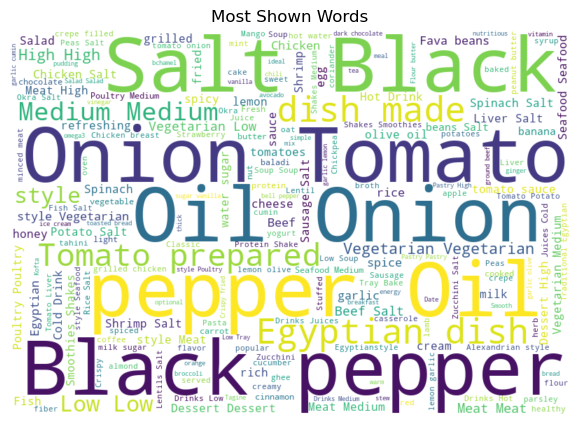

In [115]:
combined_text = ' '.join(df['Selected_Cols'])
wordcloud = WordCloud(height=550 , width=800 , background_color="white").generate(combined_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud,interpolation = "bilinear")
plt.axis("off")
plt.title("Most Shown Words")
plt.show()

# Converting Data Frame into Nums :

In [117]:
vec = TfidfVectorizer(stop_words='english')
df_after_vectorizer = vec.fit_transform(df['Selected_Cols'])
df_after_vectorizer

<760x920 sparse matrix of type '<class 'numpy.float64'>'
	with 9688 stored elements in Compressed Sparse Row format>

# User Input and Getting Close Match :

In [119]:
DISEASE_RESTRICTIONS = {
    'diabetes': {
        'max_carbs': 45,
        'forbidden_categories_ar': ['حلويات'],
        'forbidden_categories_en': ['Dessert'],
        'forbidden_words_ar': ['شوكولاتة', 'سكر', 'عسل', 'شيرة', 'كراميل','نوتيلا', 'توفي', 'حلوى', 'آيس كريم', 'بوظة','كيك', 'بسكويت', 'تارت', 'بودينغ'],
        'forbidden_words_en': ['chocolate', 'sugar', 'honey', 'syrup', 'caramel','nutella', 'toffee', 'candy', 'ice cream','cake', 'cookie', 'tart', 'pudding'],
    },
    'pressure': {
        # الضغط: نتجنب الأكل المصنّع والمملح - مش كل اللحوم والأسماك
        'forbidden_categories_ar': ['معجنات', 'مشروبات', 'مشروبات ساخنة'],
        'forbidden_categories_en': ['Pastry', 'Beverages', 'Hot Drinks'],
        'forbidden_words_ar': ['مخلل', 'مملح', 'مدخن', 'سجق', 'بسطرمة', 'رنجة', 'فسيخ'],
        'forbidden_words_en': ['pickled', 'salted', 'smoked', 'sausage', 'pastirma', 'cured'],
        'max_fats': 25,                                     # دهون عالية ترفع الضغط
    },
    'heart': {
        'max_fats': 15,
        # الكلمات الممنوعة - نفحص في الاسم والمكونات
        'forbidden_words_ar': ['كبد', 'سجق', 'بسطرمة', 'رنجة', 'فسيخ', 'مخ', 'قلب'],
        'forbidden_words_en': ['liver', 'sausage', 'pastirma', 'herring', 'brain', 'heart meat'],
        # تجنب المقلي
        'forbidden_cooking_words_ar': ['مقلي', 'محمر'],
    },
    'allergy': {
        'check_ingredients': True
        # allergy_ingredients تتجي من المستخدم
    }}

In [120]:
def filter_by_diseases(food_names_list, diseases_list=None, allergy_ingredients=None):
    if not diseases_list:
        return food_names_list
    
    filtered_foods = []
    for food_name in food_names_list:
        food_data = df[df['food_name_ar'] == food_name]
        if food_data.empty:
            continue
        
        food_row = food_data.iloc[0]
        is_allowed = True
        
        for disease in diseases_list:
            if disease == 'diabetes':
                if food_row['carbs_per_100g'] > DISEASE_RESTRICTIONS['diabetes']['max_carbs']:
                    is_allowed = False
                    break
                if food_row['main_category_ar'] in DISEASE_RESTRICTIONS['diabetes']['forbidden_categories_ar']:
                    is_allowed = False
                    break
                # contains check في الاسم والمكونات
                combined_ar = food_name.lower() + ' ' + str(food_row['ingredients_ar']).lower()
                if any(w in combined_ar for w in DISEASE_RESTRICTIONS['diabetes']['forbidden_words_ar']):
                    is_allowed = False
                    break
                combined_en = str(food_row['food_name_en']).lower() + ' ' + str(food_row['ingredients_en']).lower()
                if any(w in combined_en for w in DISEASE_RESTRICTIONS['diabetes']['forbidden_words_en']):
                    is_allowed = False
                    break
            
            # Pressure: avoid high sodium foods
            elif disease == 'pressure':
                if food_row['main_category_ar'] in DISEASE_RESTRICTIONS['pressure']['forbidden_categories_ar']:
                    is_allowed = False
                    break
                if food_row['fats_per_100g'] > DISEASE_RESTRICTIONS['pressure']['max_fats']:
                    is_allowed = False
                    break
                combined_ar = food_name.lower() + ' ' + str(food_row['ingredients_ar']).lower()
                if any(w in combined_ar for w in DISEASE_RESTRICTIONS['pressure']['forbidden_words_ar']):
                    is_allowed = False
                    break
                combined_en = str(food_row['main_category_en']).lower() + ' ' + str(food_row['ingredients_en']).lower()
                if any(w in combined_en for w in DISEASE_RESTRICTIONS['pressure']['forbidden_words_en']):
                    is_allowed = False
                    break
            
            # Heart: max fats 15g, avoid high cholesterol
            elif disease == 'heart':
                if food_row['fats_per_100g'] > DISEASE_RESTRICTIONS['heart']['max_fats']:
                    is_allowed = False
                    break
                combined_ar = food_name.lower() + ' ' + str(food_row['ingredients_ar']).lower()
                if any(w in combined_ar for w in DISEASE_RESTRICTIONS['heart']['forbidden_words_ar']):
                    is_allowed = False
                    break
                combined_en = str(food_row['food_name_en']).lower() + ' ' + str(food_row['ingredients_en']).lower()
                if any(w in combined_en for w in DISEASE_RESTRICTIONS['heart']['forbidden_words_en']):
                    is_allowed = False
                    break
                if any(w in food_name.lower() for w in DISEASE_RESTRICTIONS['heart']['forbidden_cooking_words_ar']):
                    is_allowed = False
                    break
            
            # Allergy: check ingredients
            elif disease == 'allergy' and allergy_ingredients:
                ingredients = str(food_row['ingredients_ar']).lower()
                if any(allergen.lower() in ingredients for allergen in allergy_ingredients):
                    is_allowed = False
                    break
        
        if is_allowed:
            filtered_foods.append(food_name)
    return filtered_foods

In [121]:
def Calc_cosine():
    sim_socre = cosine_similarity(df_after_vectorizer)
    with open('sim_score.pkl', 'wb') as f:
        pickle.dump(sim_socre, f)

In [122]:
def Recommendation(User_Input, diseases_list=None, allergy_ingredients=None):
    try:
        with open('sim_score.pkl', 'rb') as f:
            sim_score = pickle.load(f)
    except:
        Calc_cosine()
        with open('sim_score.pkl', 'rb') as f:
            sim_score = pickle.load(f)

    Food_list = df["food_name_en"].to_list()
    Closest_match = get_close_matches(User_Input, Food_list)

    if not Closest_match:
        print("Food is Not Similar Enough! Enter it Correctly or Try Typing Another one.")
        return

    closest = Closest_match[0]
    matching_ratio = SequenceMatcher(None, User_Input.lower(), closest.lower()).ratio()

    if matching_ratio < 0.75:
        print("Food is Not Found in The Dataset! Enter Another one.")
        return

    input_index = df[df.food_name_en == closest].index[0]
    sim_score_list = list(enumerate(sim_score[input_index]))
    sorted_sim_score = sorted(sim_score_list, key=lambda x: x[1], reverse=True)

    recommendations = []
    
    i = 1
    for id, score in sorted_sim_score:
        index = id
        food_name_arabic = df.iloc[index]['food_name_ar']
        food_name_english = df.iloc[index]['food_name_en']

        if closest == food_name_english:
            continue
        
        recommendations.append((food_name_arabic, score))
        i += 1
        
        if diseases_list and i > 50:
            break
        elif not diseases_list and i > 15:
            break
    
    if diseases_list:
        food_names = [name for name, score in recommendations]
        filtered_names = filter_by_diseases(food_names, diseases_list, allergy_ingredients)
        recommendations = [(name, score) for name, score in recommendations if name in filtered_names]
    
    Final_dict = recommendations[:15]
    return Final_dict

# Second Part : Collaborative Filtering :

In [124]:
from surprise import Reader, Dataset, SVD
from surprise.model_selection import train_test_split
from surprise import accuracy

In [132]:
ratings_df = df.iloc[:, 16:].drop('Selected_Cols',axis=1)
ratings_df['food_id'] = df['food_id']
ratings_df

,user_1_rating,user_2_rating,user_3_rating,user_4_rating,user_5_rating,user_6_rating,user_7_rating,user_8_rating,user_9_rating,user_10_rating,...,user_12_rating,user_13_rating,user_14_rating,user_15_rating,user_16_rating,user_17_rating,user_18_rating,user_19_rating,user_20_rating,food_id
0,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,2.0,NaN,...,NaN,NaN,NaN,4.0,2.0,2.0,NaN,NaN,5.0,1
1,NaN,NaN,5.0,NaN,NaN,4.0,3.0,NaN,NaN,NaN,...,3.0,1.0,NaN,5.0,NaN,NaN,NaN,1.0,2.0,2
2,NaN,NaN,NaN,NaN,1.0,NaN,3.0,NaN,NaN,NaN,...,NaN,NaN,NaN,5.0,NaN,NaN,1.0,NaN,1.0,3
3,5.0,1.0,NaN,3.0,NaN,NaN,NaN,NaN,1.0,3.0,...,NaN,3.0,NaN,NaN,3.0,NaN,NaN,NaN,NaN,4
4,4.0,NaN,NaN,NaN,NaN,NaN,4.0,4.0,NaN,3.0,...,NaN,2.0,NaN,NaN,NaN,NaN,3.0,NaN,NaN,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
755,NaN,NaN,NaN,NaN,NaN,NaN,1.0,5.0,3.0,NaN,...,NaN,NaN,NaN,3.0,NaN,5.0,4.0,NaN,3.0,30182
756,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,1.0,NaN,...,1.0,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,30183
757,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,4.0,NaN,...,4.0,NaN,NaN,4.0,1.0,NaN,NaN,NaN,3.0,30184
758,NaN,4.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,1.0,...,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,5.0,30185


In [134]:
ratings_df.isna().sum()

user_1_rating     417
user_2_rating     558
user_3_rating     566
user_4_rating     501
user_5_rating     436
user_6_rating     558
user_7_rating     536
user_8_rating     514
user_9_rating     480
user_10_rating    450
user_11_rating    584
user_12_rating    512
user_13_rating    393
user_14_rating    555
user_15_rating    549
user_16_rating    542
user_17_rating    510
user_18_rating    488
user_19_rating    565
user_20_rating    469
food_id             0
dtype: int64

In [136]:
for col in ratings_df.columns:
  val_counts = ratings_df[col].value_counts()
  print(f"{col} : {val_counts}")

user_1_rating : user_1_rating
5.0    79
3.0    71
4.0    68
2.0    68
1.0    57
Name: count, dtype: int64
user_2_rating : user_2_rating
4.0    45
1.0    42
5.0    42
3.0    37
2.0    36
Name: count, dtype: int64
user_3_rating : user_3_rating
5.0    46
2.0    41
1.0    36
4.0    36
3.0    35
Name: count, dtype: int64
user_4_rating : user_4_rating
4.0    57
1.0    55
5.0    50
2.0    49
3.0    48
Name: count, dtype: int64
user_5_rating : user_5_rating
4.0    75
1.0    67
2.0    64
3.0    63
5.0    55
Name: count, dtype: int64
user_6_rating : user_6_rating
1.0    47
4.0    42
5.0    39
3.0    38
2.0    36
Name: count, dtype: int64
user_7_rating : user_7_rating
5.0    50
3.0    47
2.0    46
1.0    41
4.0    40
Name: count, dtype: int64
user_8_rating : user_8_rating
5.0    54
2.0    50
3.0    49
1.0    48
4.0    45
Name: count, dtype: int64
user_9_rating : user_9_rating
4.0    72
5.0    60
1.0    52
2.0    50
3.0    46
Name: count, dtype: int64
user_10_rating : user_10_rating
4.0    70
1.0 

In [138]:
ratings_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 760 entries, 0 to 759
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_1_rating   343 non-null    float64
 1   user_2_rating   202 non-null    float64
 2   user_3_rating   194 non-null    float64
 3   user_4_rating   259 non-null    float64
 4   user_5_rating   324 non-null    float64
 5   user_6_rating   202 non-null    float64
 6   user_7_rating   224 non-null    float64
 7   user_8_rating   246 non-null    float64
 8   user_9_rating   280 non-null    float64
 9   user_10_rating  310 non-null    float64
 10  user_11_rating  176 non-null    float64
 11  user_12_rating  248 non-null    float64
 12  user_13_rating  367 non-null    float64
 13  user_14_rating  205 non-null    float64
 14  user_15_rating  211 non-null    float64
 15  user_16_rating  218 non-null    float64
 16  user_17_rating  250 non-null    float64
 17  user_18_rating  272 non-null    flo

In [140]:
user_rating_cols = [f'user_{i}_rating' for i in range(1, 21)]
# بعمل rows بعدد التقييمات لليوزر الواحد
# بيثبت الاول ويفك التاني والتالت اسم عمود يشيل اسماء الاعمدة اللي اتفكت والاخير يشيل القيم اللي كانت ف الاعمدة
new_long_ratings = ratings_df.melt(id_vars='food_id', value_vars=user_rating_cols, var_name='userId', value_name='rating')

new_long_ratings['userId'] = new_long_ratings['userId'].str.extract('(\d+)').astype(int)
new_long_ratings = new_long_ratings.dropna()
new_long_ratings

<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
C:\Users\muhaned\AppData\Local\Temp\ipykernel_21604\1104932113.py:6: SyntaxWarning: invalid escape sequence '\d'
  new_long_ratings['userId'] = new_long_ratings['userId'].str.extract('(\d+)').astype(int)


,food_id,userId,rating
3,4,1,5.0
4,5,1,4.0
5,6,1,3.0
10,11,1,3.0
11,12,1,1.0
...,...,...,...
15194,30181,20,4.0
15195,30182,20,3.0
15197,30184,20,3.0
15198,30185,20,5.0


In [142]:
def svd_training_calculation():
    reader = Reader(rating_scale=(1,5))
    dataset = Dataset.load_from_df(new_long_ratings[['userId','food_id','rating']],reader)
    trainset, testset = train_test_split(dataset, test_size=0.2, random_state=42)
    
    svd = SVD(n_factors=50 ,n_epochs=50 ,lr_all=0.005, reg_all=0.02, random_state=42)
    svd.fit(trainset)
    predictions = svd.test(testset)
    accuracy.rmse(predictions) 
    accuracy.mae(predictions)

    with open("svd_training.pkl",'wb') as f:
        pickle.dump(svd,f)

In [144]:
svd_training_calculation()

RMSE: 1.5197
MAE:  1.3023


In [146]:
def Collaborative_filtering(user_id, num_of_recommendations=10, diseases_list=None, allergy_ingredients=None):
    try: 
        with open("svd_training.pkl",'rb') as f:
            svd = pickle.load(f)
    except:
        svd_training_calculation()
        with open("svd_training.pkl",'rb') as f:
            svd = pickle.load(f)

    foods_ids = set(new_long_ratings['food_id'].unique())
    eaten_food_ids = set(new_long_ratings[new_long_ratings['userId'] == user_id]['food_id'].unique())
    foods_to_predict = foods_ids - eaten_food_ids

    predictions = [(foodid, svd.predict(uid=user_id, iid=foodid).est) for foodid in foods_to_predict]

    # Get more if filtering
    top_count = num_of_recommendations * 3 if diseases_list else num_of_recommendations
    top_recommendations = sorted(predictions, key=lambda x: x[1], reverse=True)[:top_count]
    
    # ========== NEW: Filter by diseases ==========
    if diseases_list:
        # Convert food_id to food_name
        food_name_predictions = []
        for food_id, score in top_recommendations:
            food_name = df[df['food_id'] == food_id]['food_name_ar'].values
            if len(food_name) > 0:
                food_name_predictions.append((food_name[0], score))
        
        # Filter
        food_names = [name for name, score in food_name_predictions]
        filtered_names = filter_by_diseases(food_names, diseases_list, allergy_ingredients)
        
        result = []
        for name in filtered_names[:num_of_recommendations]:
            food_id = df[df['food_name_ar'] == name]['food_id'].values[0]
            # Find original score
            for fname, score in food_name_predictions:
                if fname == name:
                    result.append((food_id, score))
                    break
        return result
    
    return top_recommendations

In [148]:
def Weighted_Hybrid_Recommendations(user_id, food_name, diseases_list=None, allergy_ingredients=None, n_recommendations=10):
    
    content_recs = Recommendation(food_name, diseases_list, allergy_ingredients)
    content_dict = {name: score for name, score in content_recs}

    collab_dict = {}
    if user_id in new_long_ratings['userId'].unique():
        collab_recs = Collaborative_filtering(user_id, num_of_recommendations=20,diseases_list=diseases_list, allergy_ingredients=allergy_ingredients)
        for food_id, score in collab_recs:
            food_name_ar = df[df['food_id'] == food_id]['food_name_ar'].values
            if len(food_name_ar) > 0:
                collab_dict[food_name_ar[0]] = (score / 5)

    all_foods = set(content_dict.keys()) | set(collab_dict.keys())
    content_weight = 0.9
    collab_weight = 0.1
    final_list_foods = []

    for food in all_foods:
        content_score = content_dict.get(food, 0)
        collab_score = collab_dict.get(food, 0)
        
        if not collab_dict:
            final_score = content_score
        else:
            final_score = (content_score * content_weight) + (collab_score * collab_weight)
        
        final_list_foods.append((food, final_score))

    final_list_foods.sort(key=lambda x: x[1], reverse=True)
    
    # Remove duplicates and format
    seen = set()
    output_lines = [] 
    count = 0 
    for food, score in final_list_foods:
        if food in seen:
            continue
        
        food_data = df[df['food_name_ar'] == food]
        if food_data.empty:
            continue
            
        row = food_data.iloc[0]
        count += 1
        line = f"{count}. {food} - {int(row['calories_per_100g'])} سعر (بروتين: {row['protein_per_100g']} , كاربوهيدرات: {row['carbs_per_100g']} , دهون: {row['fats_per_100g']})"
        output_lines.append(line)
        seen.add(food)
        
        if count >= n_recommendations:
            break

    return output_lines

In [150]:
# بدون أمراض
Recommendation("Koshari")

[('مكرونة بالصلصة الحمراء', 0.49208113039259793),
 ('طاجن مكرونة باللحمة', 0.41008264799556093),
 ('شوربة عدس بالصلصة', 0.4062521873312724),
 ('كشري إسكندراني', 0.4046037747830573),
 ('بامية عدس بالصلصة', 0.39385305590289976),
 ('كشري بالعدس الأصفر', 0.3906048731741928),
 ('رز صيادية', 0.38613670490784424),
 ('كشري عدس في الفرن', 0.38040827648807435),
 ('كشري عدس بالبصل', 0.37900295378463483),
 ('طاجن عدس سبايسي', 0.376980335773389),
 ('لحمة بالبصل', 0.36796423958431707),
 ('شوربة عدس بلدي', 0.36795907889008755),
 ('بامية عدس سبايسي', 0.3663494055369135),
 ('كشك صعيدي', 0.3653078581830252),
 ('بامية عدس إسكندراني', 0.3626953385020223)]

In [152]:
Weighted_Hybrid_Recommendations(1,"basboussa",['diabetes','allergy'],['بيض'],10)

['1. فراخ بتر ماندي المصري - 245 سعر (بروتين: 28.0 , كاربوهيدرات: 5.0 , دهون: 13.0)',
 '2. دجاج بالزبدة - 245 سعر (بروتين: 24.0 , كاربوهيدرات: 3.0 , دهون: 16.0)',
 '3. محشي ورق عنب - 99 سعر (بروتين: 2.0 , كاربوهيدرات: 16.8 , دهون: 2.8)',
 '4. قوارع لحم بالبهارات - 290 سعر (بروتين: 22.0 , كاربوهيدرات: 3.0 , دهون: 20.0)',
 '5. كشري سجق في الفرن - 140 سعر (بروتين: 4.3 , كاربوهيدرات: 23.3 , دهون: 3.3)',
 '6. مسقعة سجق مشوي - 301 سعر (بروتين: 17.9 , كاربوهيدرات: 1.8 , دهون: 25.6)',
 '7. محشي سبانخ سبايسي - 99 سعر (بروتين: 2.0 , كاربوهيدرات: 16.8 , دهون: 2.8)',
 '8. كريب ميكس جبن - 220 سعر (بروتين: 9.0 , كاربوهيدرات: 23.0 , دهون: 10.5)',
 '9. بط بالبرتقال - 337 سعر (بروتين: 19.0 , كاربوهيدرات: 0.0 , دهون: 28.4)',
 '10. مسقعة لحمة بالصلصة - 217 سعر (بروتين: 27.3 , كاربوهيدرات: 0.0 , دهون: 11.2)']

In [154]:
Weighted_Hybrid_Recommendations(1,"basboussa",['pressure'],10)

['1. بلح الشام - 395 سعر (بروتين: 5.0 , كاربوهيدرات: 48.0 , دهون: 22.0)',
 '2. كنافة بالجبنة - 420 سعر (بروتين: 10.0 , كاربوهيدرات: 55.0 , دهون: 20.0)',
 '3. بسبوسة بالقشطة - 360 سعر (بروتين: 6.0 , كاربوهيدرات: 52.0 , دهون: 15.0)',
 '4. لقمة القاضي - 350 سعر (بروتين: 4.5 , كاربوهيدرات: 45.0 , دهون: 18.0)',
 '5. زلابية - 290 سعر (بروتين: 4.5 , كاربوهيدرات: 42.0 , دهون: 12.0)',
 '6. تيراميسو - 380 سعر (بروتين: 8.0 , كاربوهيدرات: 38.0 , دهون: 22.0)',
 '7. كنافة - 350 سعر (بروتين: 7.4 , كاربوهيدرات: 42.8 , دهون: 18.2)',
 '8. باكلافا - 428 سعر (بروتين: 6.3 , كاربوهيدرات: 51.2 , دهون: 23.0)',
 '9. بانكيك الشوكولاتة - 345 سعر (بروتين: 8.0 , كاربوهيدرات: 48.0 , دهون: 14.0)',
 '10. شوربة ام علي بالعيش البلدي - 290 سعر (بروتين: 7.0 , كاربوهيدرات: 35.0 , دهون: 14.0)']

In [156]:
Weighted_Hybrid_Recommendations(1,"Banana Protein Shake",['allergy'],['بيض'],10)

['1. مخفوق الفانيليا والموز - 195 سعر (بروتين: 22.0 , كاربوهيدرات: 24.0 , دهون: 3.0)',
 '2. مخفوق البروتين بالموز والشوكولاتة - 220 سعر (بروتين: 25.0 , كاربوهيدرات: 22.0 , دهون: 5.0)',
 '3. مخفوق بروتين الفانيليا بالتوت - 185 سعر (بروتين: 22.0 , كاربوهيدرات: 22.0 , دهون: 2.0)',
 '4. سموزي الفراولة - 152 سعر (بروتين: 21.0 , كاربوهيدرات: 13.0 , دهون: 1.8)',
 '5. سموزي المانجو بال - 136 سعر (بروتين: 13.0 , كاربوهيدرات: 17.0 , دهون: 1.8)',
 '6. سموزي التوت البري بال - 126 سعر (بروتين: 12.0 , كاربوهيدرات: 16.0 , دهون: 1.5)',
 '7. مخفوق الفراولة والشوفان - 210 سعر (بروتين: 20.0 , كاربوهيدرات: 28.0 , دهون: 3.5)',
 '8. سموزي بالشوكولاتة - 142 سعر (بروتين: 16.0 , كاربوهيدرات: 15.0 , دهون: 2.0)',
 '9. سموزي زبدة الفول السوداني - 180 سعر (بروتين: 12.0 , كاربوهيدرات: 20.0 , دهون: 8.0)',
 '10. سموزي القهوة - 105 سعر (بروتين: 20.0 , كاربوهيدرات: 10.0 , دهون: 1.2)']

In [158]:
Weighted_Hybrid_Recommendations(1,"Egyptian Beef Stew",['allergy','pressure'],['بيض'],10)

['1. لحمة بالبصل - 240 سعر (بروتين: 22.0 , كاربوهيدرات: 5.0 , دهون: 14.0)',
 '2. شوربة لحمة بالبصل - 217 سعر (بروتين: 27.3 , كاربوهيدرات: 0.0 , دهون: 11.2)',
 '3. طاجن تورلي باللحمة - 133 سعر (بروتين: 12.7 , كاربوهيدرات: 7.9 , دهون: 6.8)',
 '4. كباب حلة - 258 سعر (بروتين: 25.6 , كاربوهيدرات: 0.0 , دهون: 16.5)',
 '5. طاجن لحمة بالبصل - 230 سعر (بروتين: 20.0 , كاربوهيدرات: 5.0 , دهون: 13.0)',
 '6. محشي لحمة سبايسي - 175 سعر (بروتين: 10.0 , كاربوهيدرات: 18.0 , دهون: 8.0)',
 '7. طاجن لحمة بلدي - 228 سعر (بروتين: 21.0 , كاربوهيدرات: 3.5 , دهون: 13.0)',
 '8. فول لحمة بالبصل - 155 سعر (بروتين: 10.0 , كاربوهيدرات: 16.0 , دهون: 6.0)',
 '9. ساندويتش لحمة مشوي - 230 سعر (بروتين: 18.0 , كاربوهيدرات: 22.0 , دهون: 9.5)',
 '10. فول لحمة سبايسي - 160 سعر (بروتين: 10.0 , كاربوهيدرات: 16.5 , دهون: 6.5)']